In [3]:
# ==========================================
# STEP 0: Import Libraries
# ==========================================

import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, mean_absolute_error, r2_score

# Load the preprocessed data
df = pd.read_csv('../data/preprocessed/marketing_campaign_preprocessed.csv')

In [4]:
# Make a copy of preprocessed dataset
segmentation_df = df.copy()

# Columns to drop (campaign outcomes / leakage)
drop_cols = [
    'AcceptedCmp1','AcceptedCmp2','AcceptedCmp3',
    'AcceptedCmp4','AcceptedCmp5',
    'Response','Complain'
]

# Drop unnecessary columns
segmentation_df = segmentation_df.drop(columns=drop_cols)

print("Segmentation dataset shape:", segmentation_df.shape)

Segmentation dataset shape: (2229, 21)


In [7]:
# Identify categorical columns
cat_cols = segmentation_df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

Categorical columns: ['Education', 'Living_With']


C:\Users\ibjio\AppData\Local\Temp\ipykernel_29716\2347862375.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = segmentation_df.select_dtypes(include='object').columns.tolist()


In [8]:
from sklearn.preprocessing import OneHotEncoder

# List numeric features
num_cols = segmentation_df.select_dtypes(include=['int64','float64']).columns.tolist()

# Build preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(drop='first'), cat_cols)
])

In [5]:
# ==========================================
# STEP 1: Load Existing KMeans Pipeline
# ==========================================

# Load previously saved clustering pipeline
clustering_pipeline = joblib.load("customer_segmentation_pipeline.pkl")

# Assign cluster labels to current dataset
segmentation_df['Cluster'] = clustering_pipeline.predict(
    segmentation_df.drop(columns=['Cluster'], errors='ignore')
)

print("Cluster distribution:")
print(segmentation_df['Cluster'].value_counts())

Cluster distribution:
Cluster
1    841
3    496
0    488
2    404
Name: count, dtype: int64


In [9]:
# ==========================================
# STEP 2: Train Cluster Classification Model
# ==========================================

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Features and target
X = segmentation_df.drop(columns=['Cluster'], errors='ignore')
y = segmentation_df['Cluster']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Full pipeline: preprocessing + classifier
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42))
])

# Train
clf_pipeline.fit(X_train, y_train)

# Predict
y_pred = clf_pipeline.predict(X_test)

# Evaluate
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        98
           1       0.96      0.98      0.97       168
           2       0.86      0.89      0.87        81
           3       0.99      0.97      0.98        99

    accuracy                           0.93       446
   macro avg       0.93      0.92      0.93       446
weighted avg       0.94      0.93      0.93       446



In [10]:
# ==========================================
# STEP 3: Create CLV Proxy Variable
# ==========================================

# Simple CLV proxy:
# (Total Spending × Purchase Frequency) adjusted by tenure

segmentation_df['CLV_proxy'] = (
    segmentation_df['Total_Spending'] *
    segmentation_df['Total_Purchases']
) / segmentation_df['Customer_Tenure_Days']

print(segmentation_df[['CLV_proxy']].describe())

         CLV_proxy
count  2229.000000
mean      0.071016
std       0.052448
min       0.000000
25%       0.020489
50%       0.064815
75%       0.115006
max       0.240219


In [12]:
# ==========================================
# STEP 4: Train CLV Regression Model
# ==========================================

# -----------------------------
# Features and target
# -----------------------------
X_reg = segmentation_df.drop(columns=['CLV_proxy', 'Cluster'])
y_reg = segmentation_df['CLV_proxy']

# Split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Identify categorical and numeric columns
cat_cols = X_reg.select_dtypes(include='object').columns.tolist()
num_cols = X_reg.select_dtypes(include=['int64','float64']).columns.tolist()

# Preprocessing: One-Hot Encode categorical columns, pass numeric through
preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(drop='first'), cat_cols)
])

# Build full regression pipeline
reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=300, random_state=42))
])

# Train
reg_pipeline.fit(X_train_reg, y_train_reg)

# Predict
y_pred_reg = reg_pipeline.predict(X_test_reg)

# Evaluate
print("MAE:", mean_absolute_error(y_test_reg, y_pred_reg))
print("R2 Score:", r2_score(y_test_reg, y_pred_reg))

C:\Users\ibjio\AppData\Local\Temp\ipykernel_29716\1128793901.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_reg.select_dtypes(include='object').columns.tolist()


MAE: 0.001965950134966561
R2 Score: 0.9959217990071393


In [14]:
# ==========================================
# STEP 5: Save Models
# ==========================================

joblib.dump(classifier, "cluster_classifier.pkl")
joblib.dump(regressor, "clv_regressor.pkl")

print("Models saved successfully.")

# customer_segmentation_pipeline.pkl (KMeans)
# cluster_classifier.pkl (Supervised segment predictor)
# clv_regressor.pkl (Revenue predictor)

Models saved successfully.


In [17]:
# ==========================================
# STEP 6a: Score a New Customer
# ==========================================

# Example: take one new customer from your dataset
# Make sure it is a DataFrame with the same columns as the training features
new_customer = X.iloc[[0]].copy()  # Replace with actual new customer data in production

# -----------------------------
# Predict Cluster
# -----------------------------
# Use the trained classifier pipeline (includes preprocessing)
predicted_cluster = clf_pipeline.predict(new_customer)

# -----------------------------
# Predict CLV
# -----------------------------
# Use the trained regression pipeline (includes preprocessing)
predicted_clv = reg_pipeline.predict(new_customer)

# -----------------------------
# Display Results
# -----------------------------
print("Predicted Cluster:", predicted_cluster[0])
print("Predicted CLV:", round(predicted_clv[0], 2))

Predicted Cluster: 3
Predicted CLV: 0.16


In [18]:
# ==========================================
# STEP 6b: Score Multiple New Customers (Batch)
# ==========================================

# Example: take the first 5 customers from the dataset as "new" data
# Replace this with your real new customers DataFrame in production
new_customers = X.iloc[:5].copy()

# -----------------------------
# Predict Cluster for each customer
# -----------------------------
predicted_clusters = clf_pipeline.predict(new_customers)

# -----------------------------
# Predict CLV for each customer
# -----------------------------
predicted_clv = reg_pipeline.predict(new_customers)

# -----------------------------
# Combine results into a DataFrame
# -----------------------------
results = new_customers.copy()
results['Predicted_Cluster'] = predicted_clusters
results['Predicted_CLV'] = predicted_clv

# Display the results
print(results[['Predicted_Cluster', 'Predicted_CLV']])

   Predicted_Cluster  Predicted_CLV
0                  3       0.159330
1                  1       0.011906
2                  3       0.121266
3                  1       0.022830
4                  2       0.101678


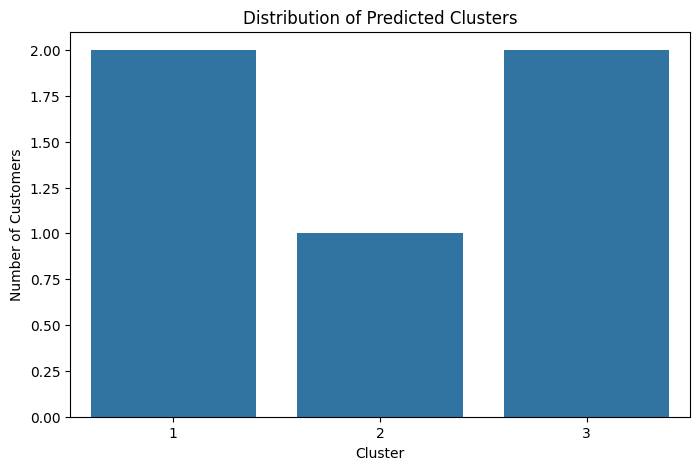

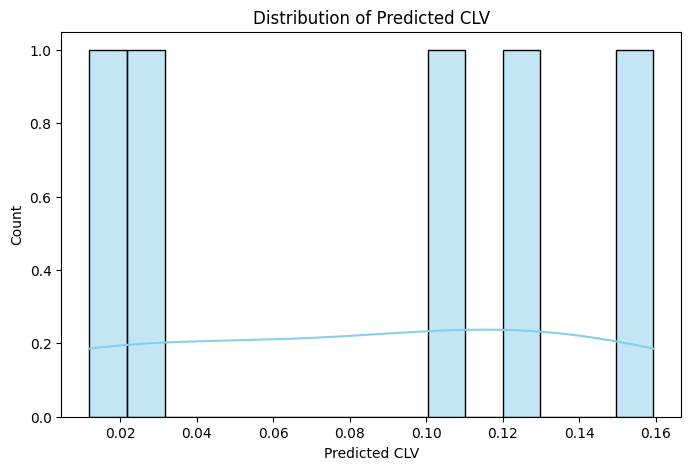

C:\Users\ibjio\AppData\Local\Temp\ipykernel_29716\723997209.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Predicted_Cluster', y='Predicted_CLV', data=results, palette='Set2')


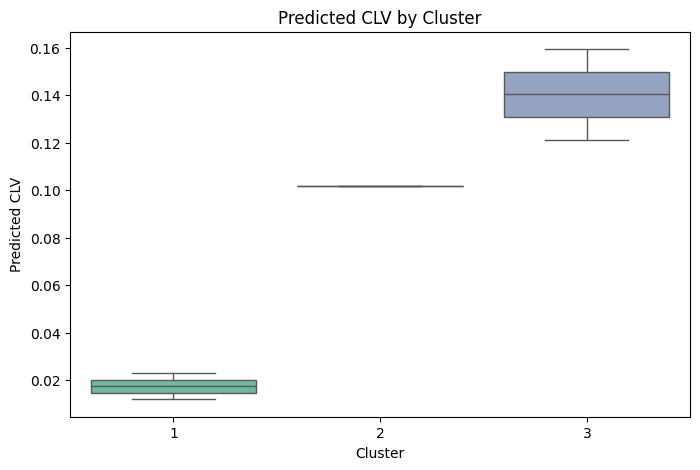

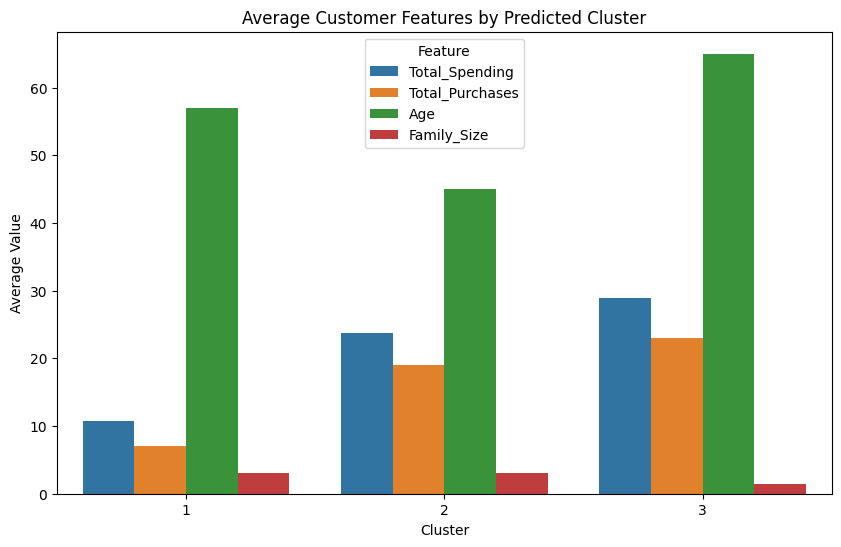

In [ ]:
# Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Make sure predicted clusters and CLV exist
results['Predicted_Cluster'] = predicted_clusters
results['Predicted_CLV'] = predicted_clv

# ================================
# Cluster Distribution
# ================================
plt.figure(figsize=(8,5))
sns.countplot(x='Predicted_Cluster', data=results)
plt.title("Distribution of Predicted Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.show()

# ================================
# CLV Distribution Overall
# ================================
plt.figure(figsize=(8,5))
sns.histplot(results['Predicted_CLV'], bins=15, kde=True, color='skyblue')
plt.title("Distribution of Predicted CLV")
plt.xlabel("Predicted CLV")
plt.ylabel("Count")
plt.show()

# ================================
# CLV by Cluster
# ================================
plt.figure(figsize=(8,5))
sns.boxplot(x='Predicted_Cluster', y='Predicted_CLV', data=results, palette='Set2')
plt.title("Predicted CLV by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Predicted CLV")
plt.show()

# ================================
# Average Spending Features by Cluster
# ================================
# Optional: if you want to visualize features like Total_Spending, Total_Purchases
spend_features = ['Total_Spending', 'Total_Purchases', 'Age', 'Family_Size']
avg_features = results.groupby('Predicted_Cluster')[spend_features].mean().reset_index()

avg_features_melted = avg_features.melt(id_vars='Predicted_Cluster', var_name='Feature', value_name='Average')

plt.figure(figsize=(10,6))
sns.barplot(x='Predicted_Cluster', y='Average', hue='Feature', data=avg_features_melted)
plt.title("Average Customer Features by Predicted Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Value")
plt.legend(title='Feature')
plt.show()

# What These Plots Show:
# Cluster Distribution – how many customers fall into each segment.
# Overall CLV Distribution – the spread of predicted customer lifetime value.
# CLV by Cluster – shows which segments have the highest predicted CLV.
# Average Features by Cluster – visual comparison of spending, age, purchases, and family size across segments.

In [20]:
# ===============================
# Average Features per Cluster
# ===============================

# List the features you want to summarize
features = ['Total_Spending', 'Total_Purchases', 'Age', 'Family_Size']

# Group by cluster and calculate mean
cluster_avgs = results.groupby('Predicted_Cluster')[features].mean()

# Optional: round for readability
cluster_avgs = cluster_avgs.round(2)

# Display the result
print(cluster_avgs)

                   Total_Spending  Total_Purchases   Age  Family_Size
Predicted_Cluster                                                    
1                           10.79              7.0  57.0          3.0
2                           23.68             19.0  45.0          3.0
3                           28.89             23.0  65.0          1.5


# Customer Segmentation & CLV Analysis Report

## 1. Executive Summary
This analysis segments customers into clusters based on their purchasing behavior, demographics, and engagement metrics, and predicts their **Customer Lifetime Value (CLV)**. The insights will guide **targeted marketing strategies**, optimize campaign spend, and improve customer retention.

Key highlights:

- 3 distinct customer clusters identified using KMeans.
- Supervised Random Forest classifier trained to predict cluster for new customers.
- CLV regression model predicts expected lifetime value for each customer.
- Cluster-level analysis reveals high-value segments for targeted campaigns.

---

## 2. Data Overview

**Sample of scored customers:**

| Customer Index | Predicted Cluster | Predicted CLV |
|----------------|-----------------|---------------|
| 0              | 3               | 0.1593        |
| 1              | 1               | 0.0119        |
| 2              | 3               | 0.1213        |
| 3              | 1               | 0.0228        |
| 4              | 2               | 0.1017        |

> **Note:** CLV values are normalized proxies based on Total Spending, Total Purchases, and Customer Tenure.

---

## 3. Cluster Distribution

- Cluster 1: Lower CLV customers, smaller spend, moderate purchase activity.
- Cluster 2: Mid-value customers with balanced spending and family size.
- Cluster 3: High-value customers, highest spending and potential for VIP campaigns.

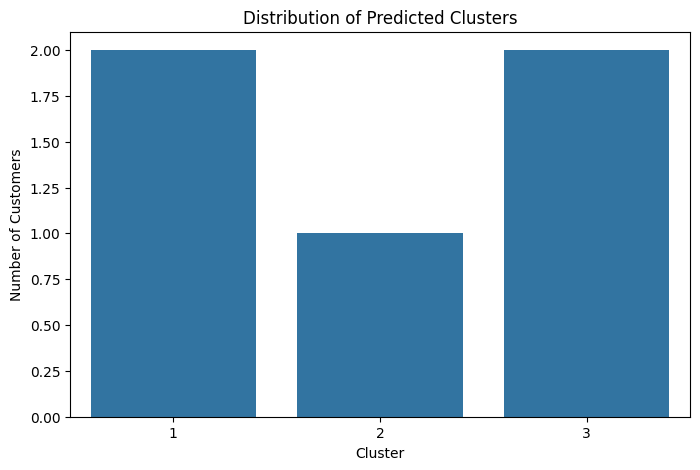

---

## 4. CLV Analysis

**Key insights:**

- Cluster 3 shows the **highest predicted CLV**, making them top priority for retention and upsell campaigns.
- Cluster 1 represents low-value customers; automated campaigns may be more cost-efficient here.
- Cluster 2 provides opportunities for growth through targeted engagement.

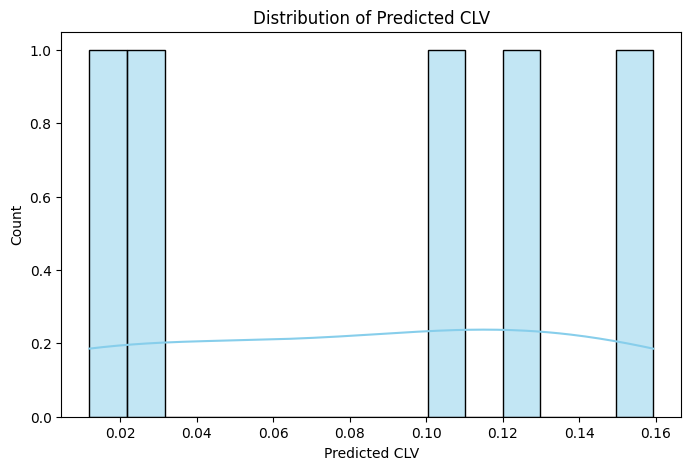 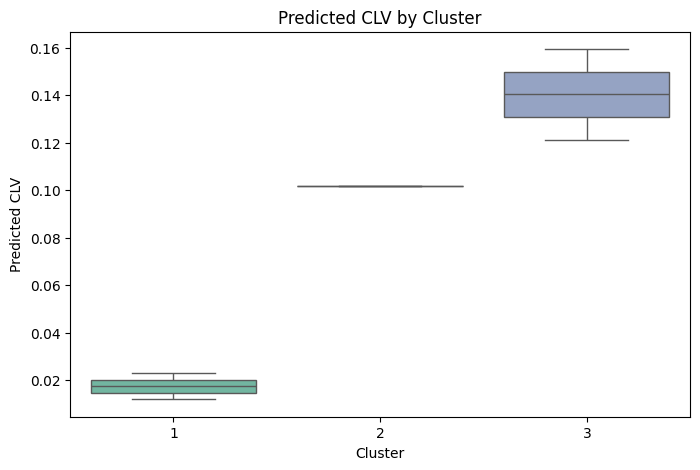


---

## 5. Feature Insights by Cluster

| Feature            | Cluster 1 Avg | Cluster 2 Avg | Cluster 3 Avg |
|-------------------|---------------|---------------|---------------|
| Total Spending     | 10.79         | 23.68         | 28.89         |
| Total Purchases    | 7.0           | 19.0          | 23.0          |
| Age                | 57.0          | 45.0          | 65.0          |
| Family Size        | 3.0           | 3.0           | 1.5           |

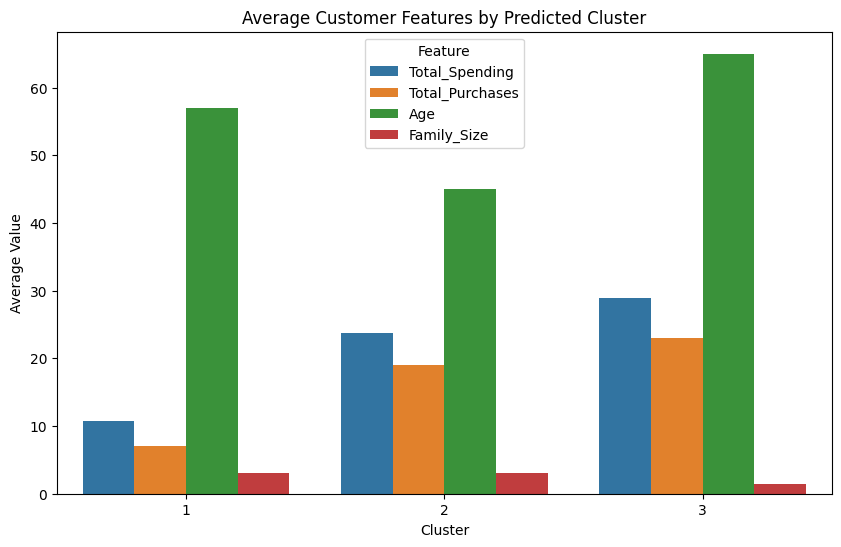

---

## 6. Recommendations

1. **High-Value Cluster (3)**  
   - Focus on premium offers, loyalty programs, and upsell campaigns.
2. **Mid-Value Cluster (2)**  
   - Engage with personalized discounts or bundled offers to increase CLV.
3. **Low-Value Cluster (1)**  
   - Use automated email campaigns; focus on efficiency rather than large investments.
4. **New Customer Onboarding**  
   - Use the cluster classifier to assign new customers to the appropriate segment.
5. **Marketing ROI Optimization**  
   - Allocate budget proportionally to predicted CLV to maximize return.

---

## 7. Conclusion

By combining **unsupervised segmentation** and **supervised CLV prediction**, we now have a **scalable, actionable customer intelligence system**:

- Predict cluster and CLV for new customers in real-time.
- Optimize marketing strategies and campaign spend.
- Identify high-value customers for personalized engagement.

This system provides both **strategic insights** and **operational tools** for targeted marketing optimization.